Filename: /home/m/Documents/science_codes/Data/Coma_Chandra/filtered_subtracted_flux.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     186   (1352, 1315)   float64   
None
Filename: /home/m/Documents/science_codes/Data/Coma_Chandra/subtracted_flux.img
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     168   (1352, 1315)   float64   
None
Filename: /home/m/Documents/science_codes/Data/Coma_Chandra/filtered_thresh.expmap
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     337   (1352, 1315)   float32   
None


[]

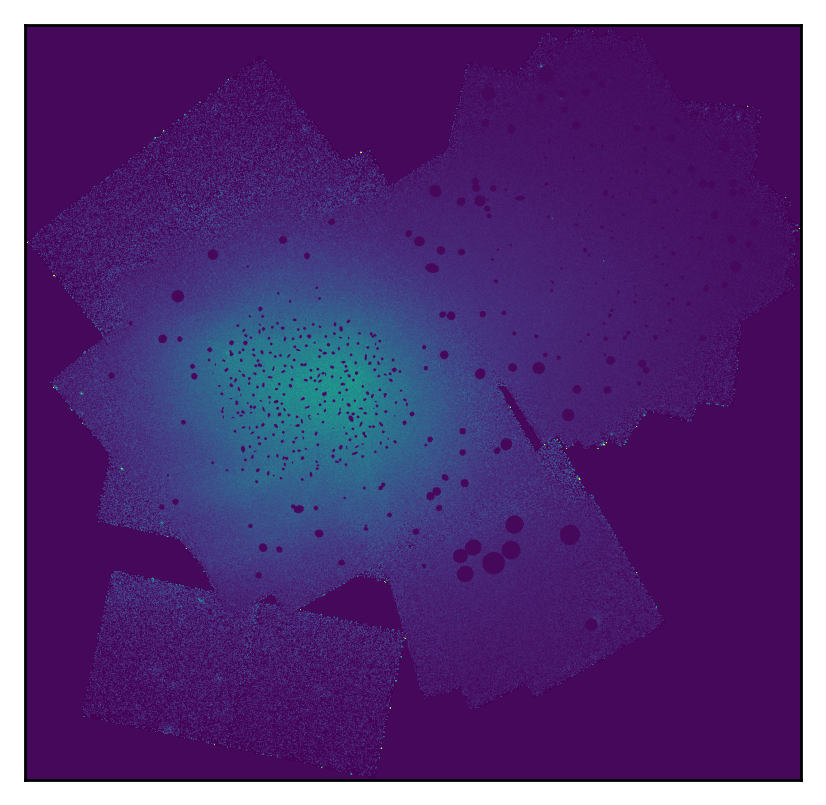

In [70]:
from astropy.io import fits
from regions import Regions
import pyregion

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import sympy as sp

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
plotting.modify_rc()

twopi = 2.*np.pi

from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

from scipy.signal import windows


#DATA_DIR = os.environ['DATA_DIR']
DATA_DIR = '/home/m/Documents/science_codes/Data/'
XRAY_DATA = DATA_DIR + 'Coma_Chandra/'

fsf = fits.open(XRAY_DATA + 'filtered_subtracted_flux.fits')
sf = fits.open(XRAY_DATA + 'subtracted_flux.img')
et = fits.open(XRAY_DATA + 'filtered_thresh.expmap')

#reg = Regions.read(XRAY_DATA + 'ds9.reg', format='ds9')
reg = pyregion.open(XRAY_DATA + 'ds9.reg').as_imagecoord(header=fsf[0].header)
filter = reg.get_filter()

mask = reg.get_mask(hdu=fsf[0])

print(fsf.info())
print(sf.info())
print(et.info())

plt.imshow(fsf[0].data, origin='lower', vmin=-9.820370487029719e-09, vmax=4.506728547715614e-07)
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])


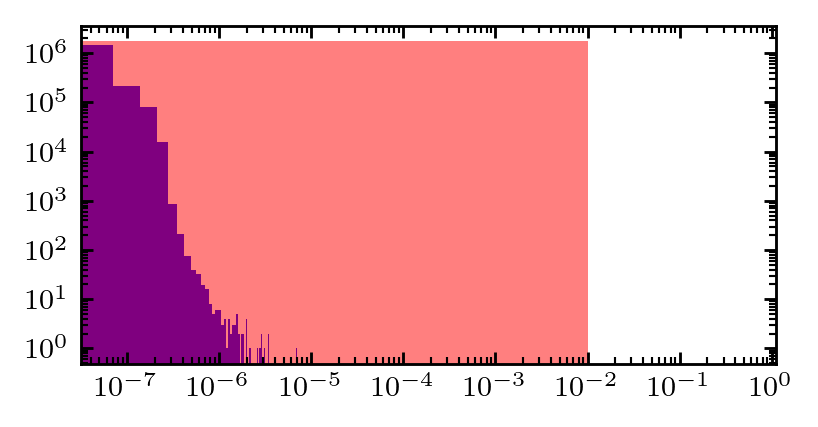

In [71]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

field0 = fsf[0].data
field0[field0 < 0.] = 0.
ax.hist(field0.flatten(), bins=100, color='blue')

field1 = -fsf[0].data
field1[field1 < 0.] = 0.
ax.hist(field1.flatten(), bins=100, color='red', alpha=0.5)

ax.set_yscale('log')
ax.set_xscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.xaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.xaxis.set_minor_locator(locmin)



Set MJD-END to 57857.084456 from DATE-END'. [astropy.wcs.wcs]


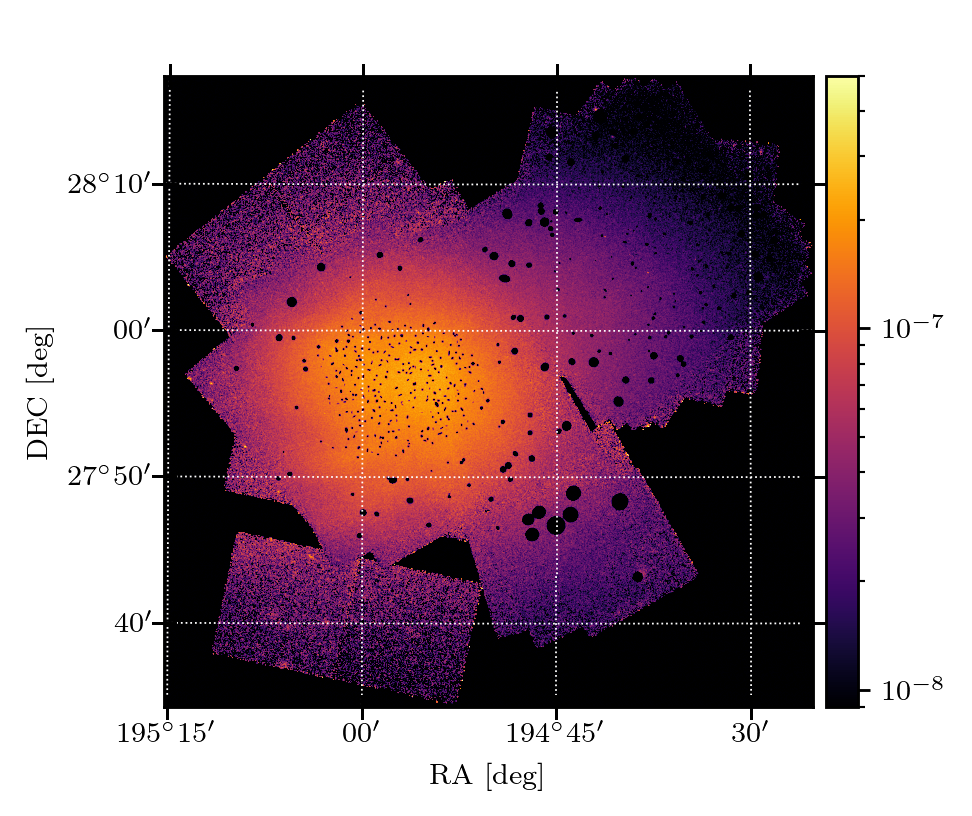

In [72]:

wcs_helix = WCS(fsf[0].header)

fig = plt.figure(figsize=(3.5, 3.5), dpi=256)
ax = plt.subplot(projection=wcs_helix)

cmap = mpl.colormaps.get('inferno')
cmap.set_bad('black')
im = ax.imshow(fsf[0].data, origin='lower', cmap=cmap, aspect='equal', norm=LogNorm(5e-7, 1e-8))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05, axes_class=maxes.Axes)
cbar = fig.colorbar(im, cax=cax, orientation='vertical')

overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='white', ls='dotted', linewidth=0.5)

overlay['ra'].set_auto_axislabel(False)
overlay['dec'].set_auto_axislabel(False)
overlay['ra'].set_ticklabel('none')
overlay['dec'].set_ticklabel('none')

ax.coords[0].set_format_unit('deg')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in', labelleft=True, labelright=False)
ax.tick_params(axis='x', direction='in', labelbottom=True, labeltop=False)

ax.set_ylabel('DEC [deg]')
ax.set_xlabel('RA [deg]')


[]

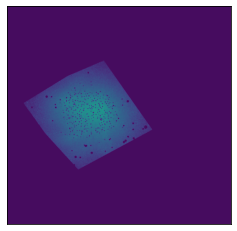

In [3]:
core = fsf[0].data * mask
et_core = et[0].data * mask
plt.imshow(core, origin='lower')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

[]

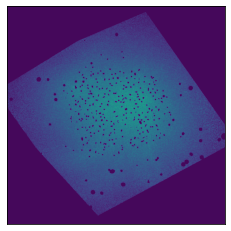

In [4]:
core2_left = (137,737)
core2_right = (840,568)
#core2_up = (572,961)
#core2_down = (428,346)
core2_up = (572,961+44)
core2_down = (428,346-44)
core2 = core[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]
plt.imshow(core2, origin='lower', vmin=-9.820370487029719e-09, vmax=4.506728547715614e-07, cmap='viridis')
#plt.scatter(532, 691, s=0.1, c='black', marker='x')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

In [5]:
#beta = 0.6
# rc = 245 kpc
def beta_model(shape, I0, c, rc, beta):
    grid = np.indices(shape)
    r = np.linalg.norm([grid[i,...] - c[i] for i in range(len(shape))], axis=0)
    return I0 / (1. + (r/rc)**2)**(3.*beta - 0.5)

-1.4975073676618683e-07 3.0375488793912914e-07
-3.0375488793912914e-07 3.0375488793912914e-07


[]

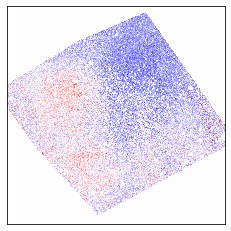

In [6]:

et_core2 = et_core[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]
combined = core2#*et_core2

c = (691, 532)
shape = (1352,1352)
I0 = core[c]*1.1
model = beta_model(shape, I0, c, 200, 0.5)
fluct = combined - model[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]
fluct[et_core2 == 0.] = 0.

pmin = - np.max([np.abs(np.max(fluct)), np.abs(np.min(fluct))])
pmax = np.max([np.abs(np.max(fluct)), np.abs(np.min(fluct))])

print(np.min(fluct), np.max(fluct))
print(pmin, pmax)

plt.imshow(fluct, origin='lower', vmin=pmin, vmax=pmax, cmap='seismic', interpolation='none')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])


[]

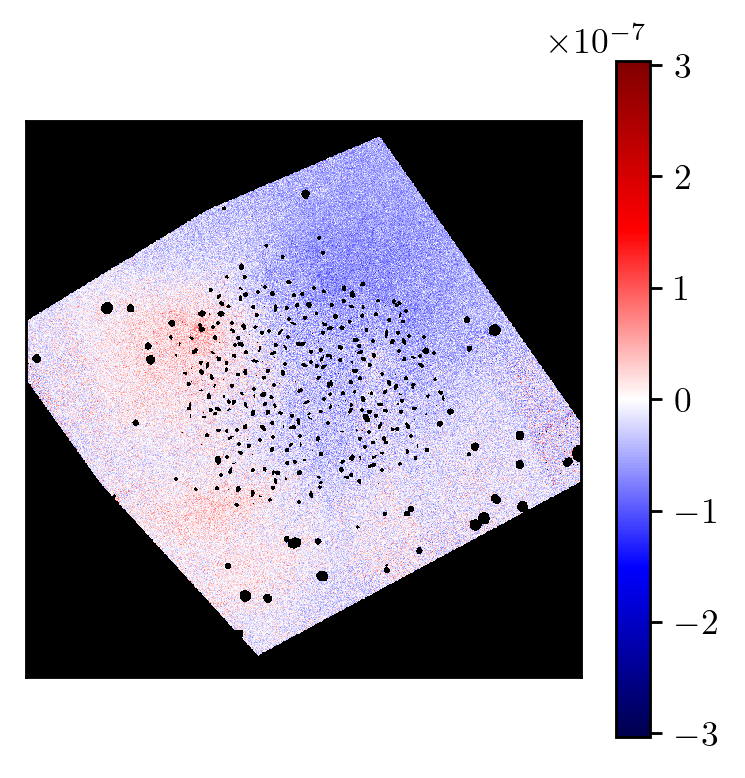

In [7]:

fmask = combined
fimage = fluct.copy()
fimage[fmask == 0.] = np.nan

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
cmap = mpl.colormaps.get('seismic')
cmap.set_bad('black')

im = ax.imshow(fimage, cmap=cmap, origin='lower', interpolation='none', vmin=pmin, vmax=pmax)
fig.colorbar(im, ax=ax)

ax.set_xticks([])
ax.set_yticks([])



In [8]:
import astropy.units as u
from astropy.cosmology import WMAP9 as cosmo

COMA_REDSHIFT = 0.0231

#CDELT2  =  5.4666666666668E-04 degrees
deltra = (fsf[0].header['CDELT1'] * u.deg).to(u.arcmin)
deltdec = (fsf[0].header['CDELT2'] * u.deg).to(u.arcmin)

d_A = cosmo.angular_diameter_distance(z=COMA_REDSHIFT)
theta = deltdec * np.max(np.shape(fluct))
print(theta)
distance_kpc = (theta * d_A).to(u.kpc, u.dimensionless_angles())
print(distance_kpc, theta.to(u.arcsec))

Lkpc = distance_kpc
Larcsec = (theta.to(u.arcsec))

Lchurazov = (14. * u.arcmin).to(u.arcsec)
print(Lchurazov)

Lc = Larcsec.value
L = [Lc, Lc]


23.058400000000564 arcmin
651.6851775474264 kpc 1383.5040000000338 arcsec
840.0 arcsec


In [9]:
from Kea.statistics.statfunc import statfunc_base, strfn

twopi = 2.*np.pi

N = fimage.shape[0]
L = Lc*N

D = 2

phys_dims = (L, L)
grid_dims = (N, N)

dk = twopi/L
dx = L/N

# lv_p = statfunc_base.get_all_lagvecs(grid_dims)
# sf_p = strfn.process_lags(fimage, fimage, lv_p, lenn=phys_dims, shape=grid_dims, orders=[2], periodic=False)[0]


In [22]:

from Kea.statistics.spectra import per_spectra, spectra_base
from Kea.statistics import statistics_base

fmask = combined
fimage = fluct.copy()
fimage[fmask == 0.] = 0.

kD, fekD = per_spectra.modal_spectrum(fimage, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)

kb, fekb, _ = statistics_base.bin_data(
    ko, feko, bin_func=np.nanmean,
    bin_loc='true_center', log_space=True, min_bin=dk, max_bin=np.nanmax(ko),
    num_bins=24)



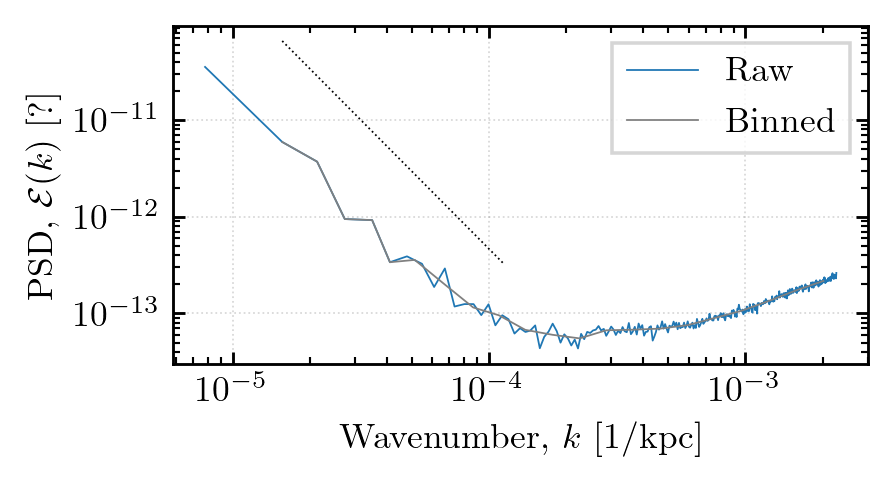

In [23]:

def plot_spec(raw, binned, title=None):
    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
    ax.plot(raw[0], raw[1], linestyle='-', linewidth=0.5, label='Raw')
    ax.plot(binned[0], binned[1], linestyle='-', color='gray', linewidth=0.5, label='Binned')
    #ax.fill_between(raw[0], raw[1]-1*raw[2], raw[1]+1*raw[2], edgecolor='none', alpha=0.5, facecolor='red')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [?]')
    ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')
    ax.legend(fancybox=False)
    ax.set_title(title)
    _k = np.exp(np.linspace(np.log(np.min(raw[0])*2), np.log(np.max(raw[0])/20), 100))
    ax.plot(_k, 1e-23*_k**(-8./3.), linestyle=':', linewidth=0.5, color='black')

plot_spec((ko, feko), (kb, fekb))
